# Cliff Gridworld — RL Algorithm Demos

All algorithms are implemented in **cliff.py**; this notebook runs them and visualises the results.

---

## Outline

| # | Section | Algorithm |
|---|---------|----------|
| 1 | Environment | — |
| 2 | Dynamic Programming | Bellman Expectation Operator |
| 3 | Dynamic Programming | Policy Iteration |
| 4 | Dynamic Programming | Value Iteration |
| 5 | Temporal Difference | TD(0) Policy Evaluation |
| 6 | Temporal Difference | SARSA vs Q-learning |
| 7 | Policy Gradient | REINFORCE, REINFORCE+baseline, Actor-Critic |


In [168]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

import cliff as _cliff_mod
importlib.reload(_cliff_mod)

from cliff import (
    CliffWorld,
    # DP
    policy_evaluation, policy_iteration, value_iteration, greedy_policy,
    # TD
    td_evaluation, sarsa, q_learning, q_to_policy, run_multiple_seeds,
    sarsa_snapshots, q_learning_snapshots,
    # Policy Gradient
    reinforce, reinforce_baseline, actor_critic,
    theta_to_policy, demo_policy_gradient,
    # Visualisation
    plot_value_function, plot_policy, plot_trajectory,
    plot_convergence, plot_delta_curve, plot_rmse_curve,
    plot_learning_curves, smooth,
    # Demos
    demo_environment, demo_bellman_operator, demo_policy_iteration,
    demo_value_iteration, demo_td_evaluation, demo_sarsa_qlearning,
)

env = CliffWorld()
print('Environment ready.  States:', env.n_states, '  Actions:', env.n_actions)

Environment ready.  States: 48   Actions: 4


---
## 1 — The Cliff Gridworld

The grid has **4 rows x 12 columns**.

* **Start S** = (3, 0) — bottom-left corner.
* **Goal G** = (3, 11) — bottom-right corner.
* **Cliff** = row 3, columns 1-10. Stepping onto the cliff gives reward **-100** and resets the agent to S.
* Every other transition gives reward **-1**.
* The episode ends (terminates) when the agent reaches G.
* Actions: Up, Down, Left, Right. Attempting to move off the grid leaves the agent in place.
* Discount factor gamma = 1 throughout these demos (undiscounted, finite-horizon task).

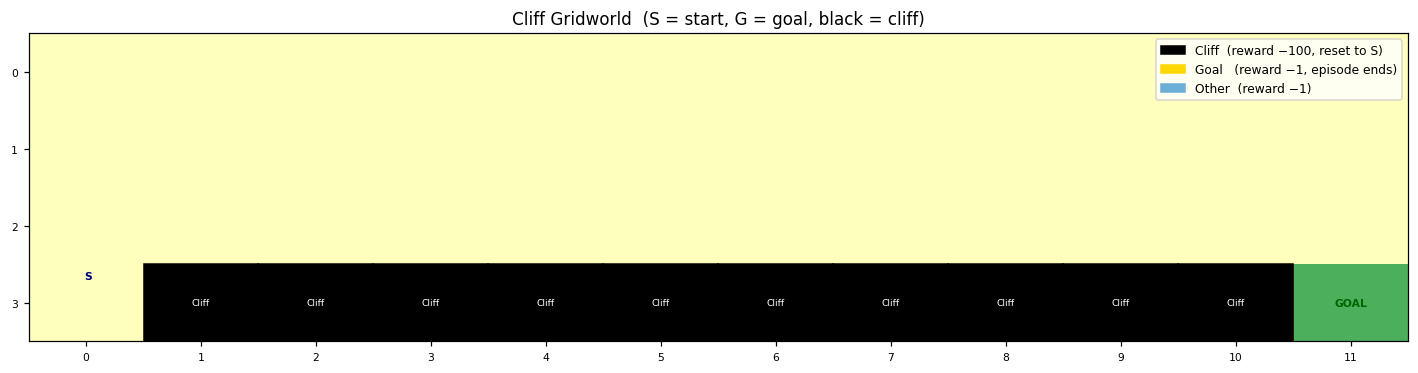

In [169]:
demo_environment(env)
plt.show()

---
## 2 — Dynamic Programming: Bellman Expectation Operator

### Background

Given a fixed policy $\pi$, the **Bellman expectation equation** defines $V^\pi$ as the unique solution of:

$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a)\bigl[r + \gamma V^\pi(s')\bigr]$$

The **Bellman operator** $\mathcal{T}^\pi$ is a $\gamma$-contraction in $\ell_\infty$.
Starting from $V_0 = \mathbf{0}$, the iterates $V_{k+1} = \mathcal{T}^\pi V_k$ converge to $V^\pi$.

### Demo policy
* Row 3: move **Up** — escape cliff row.
* Rows 0-2, columns 0-10: move **Right**.
* Rows 0-2, column 11: move **Down** — descend to goal.

In [170]:
policy_be, V_be, history_be = demo_bellman_operator(env, gamma=1.0)

Policy evaluation converged in 15 iterations.


### Value function snapshots

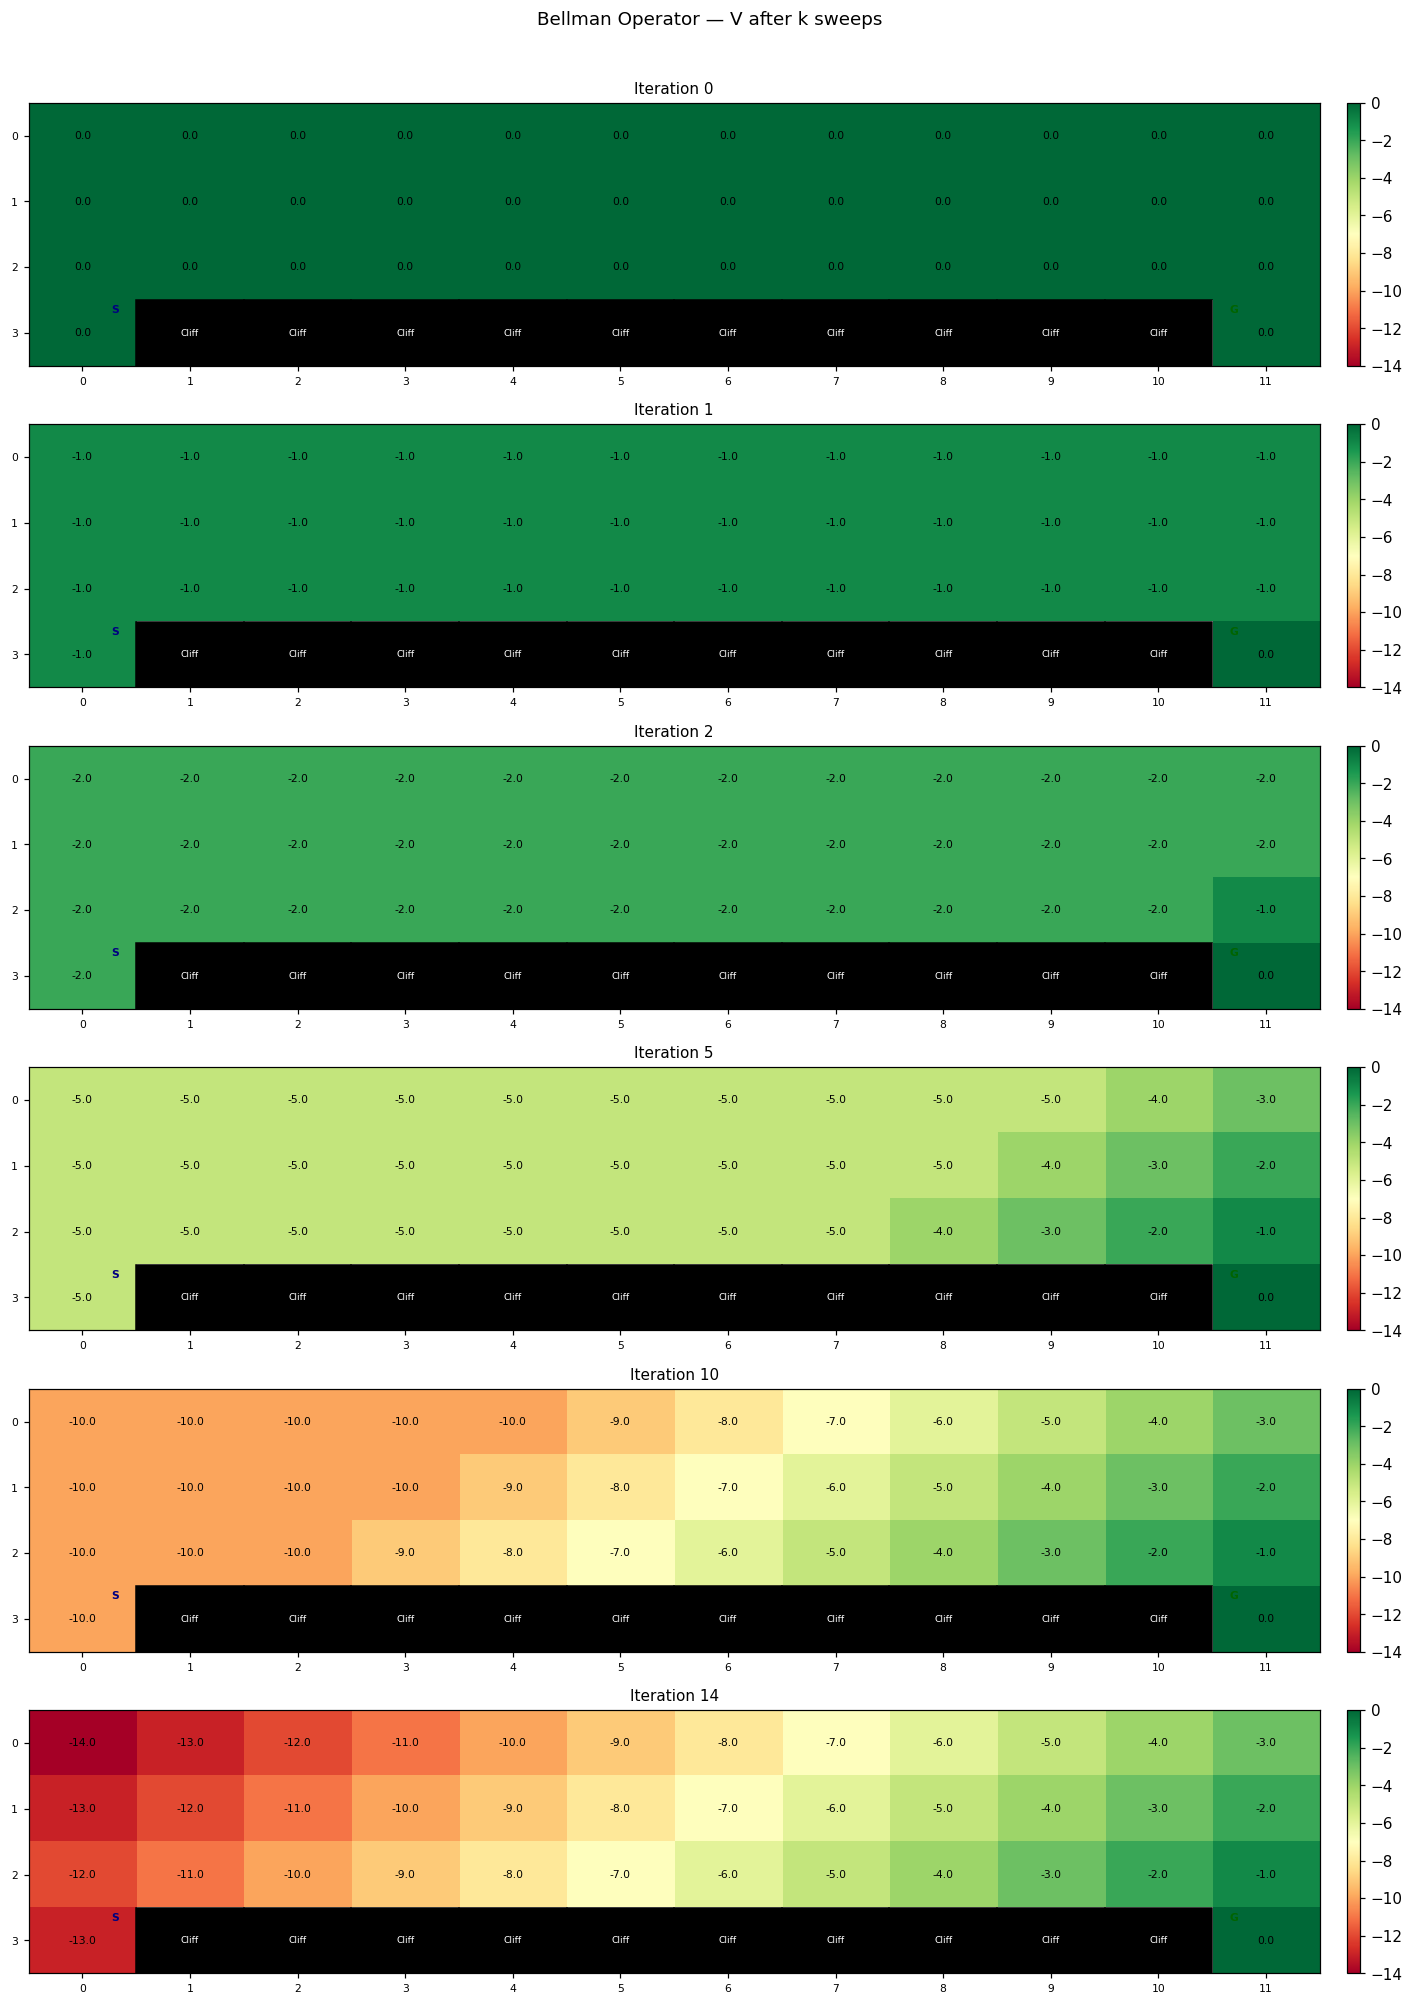

In [171]:
plot_convergence(history_be, env,
                 iterations=(0, 1, 2, 5, 10, 14),
                 title="Bellman Operator — V after k sweeps")
plt.show()

### Convergence diagnostics

**Why is max|DeltaV| a step function with gamma=1?**
With gamma=1 and uniform step cost -1, the operator propagates information exactly one hop per sweep.
Every state more than $k$ hops from the goal has the same residual error 1 at iteration $k$, so
$\|V_{k+1}-V_k\|_\infty = 1$ for all $k < h_{\max}$, then drops to 0.
The RMSE against the converged $V^\pi$ decays monotonically and is more informative.

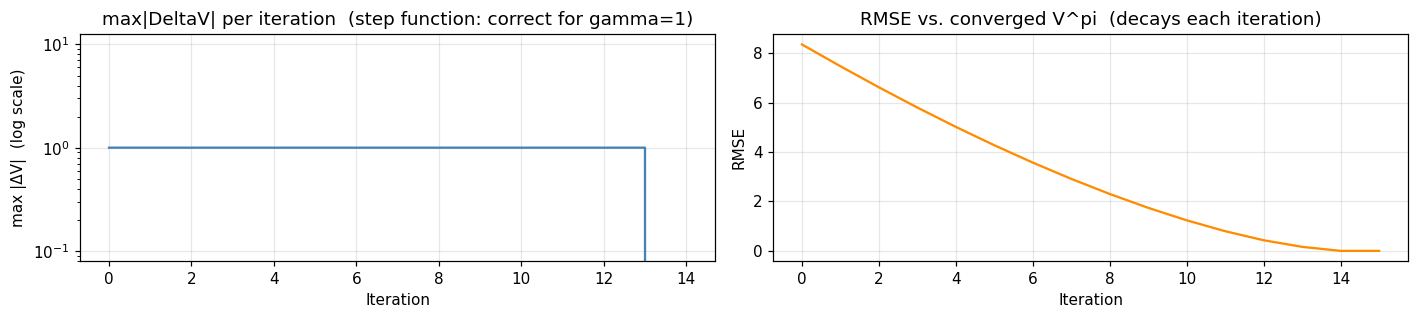

In [172]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 3))
plot_delta_curve(history_be, ax=ax_l,
                 title="max|DeltaV| per iteration  (step function: correct for gamma=1)")
plot_rmse_curve(history_be, V_ref=history_be[-1], env=env, ax=ax_r,
                title="RMSE vs. converged V^pi  (decays each iteration)")
plt.tight_layout()
plt.show()

---
## 3 — Dynamic Programming: Policy Iteration

### Background

**Policy Iteration** alternates:
1. **Policy Evaluation** — solve for $V^{\pi_k}$ exactly.
2. **Policy Improvement** — $\pi_{k+1}(s) = \arg\max_a \sum_{s',r} p(s',r|s,a)[r + \gamma V^{\pi_k}(s')]$

**Theorem (Policy Improvement):** $V^{\pi_{k+1}}(s) \ge V^{\pi_k}(s)$ for all $s$, with equality iff $\pi_k$ is already optimal.

### Initial policy
We start from a **leftward-sweep** policy that is far from optimal:
* Row 3: Up (escape cliff row)
* Col 11: Down (descend to goal)
* Row 0: Right (traverse top)
* Col 0, rows 1-2: Up (climb to top)
* Rows 1-2, cols 1-10: **Left** (sweep away from goal)

Every state eventually reaches the goal via Left* → Up* → Right* → Down*, but via a very long detour.
This requires several Policy Iteration steps to fix.

Policy Iteration converged in 13 evaluation step(s).


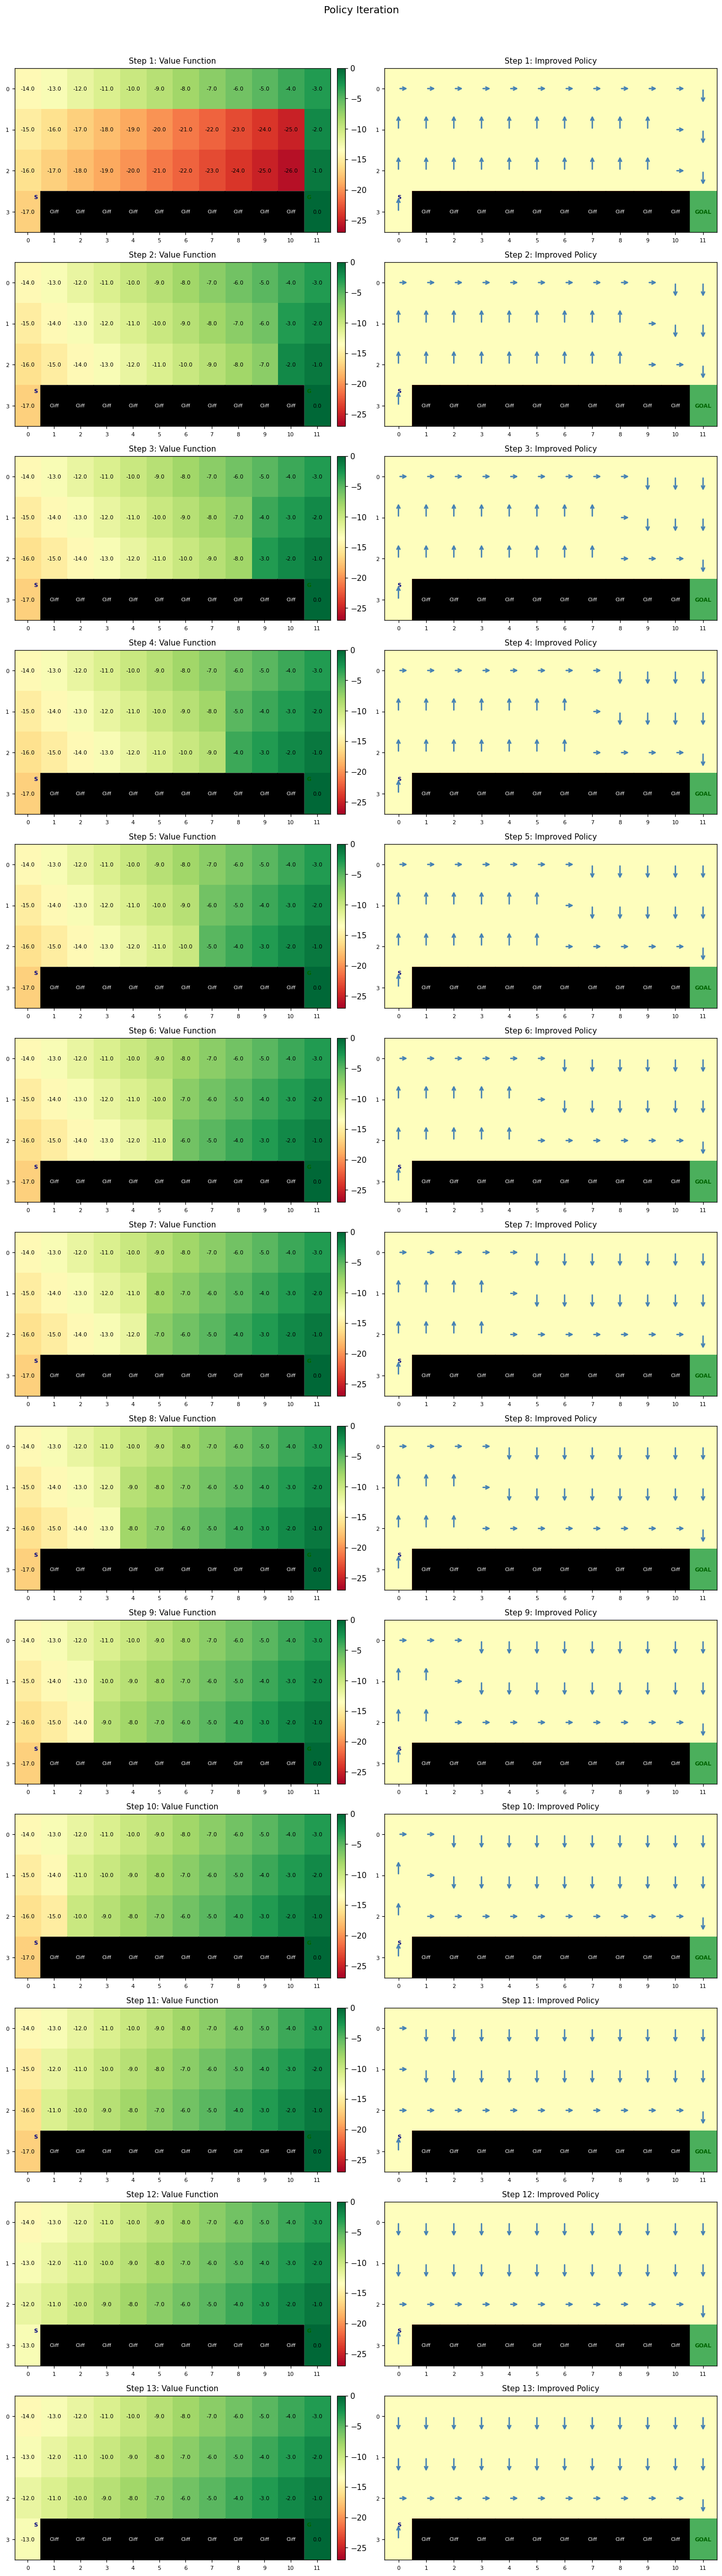

In [173]:
policy_opt, V_opt, pi_history, V_history, fig_pi = demo_policy_iteration(env, gamma=1.0)
plt.show()

**Observation:** Starting from the leftward-sweep policy, each improvement step shortens the path
until the algorithm stabilises on the optimal route along row 2.

---
## 4 — Dynamic Programming: Value Iteration

### Background

**Value Iteration** applies the **Bellman optimality operator** $\mathcal{T}^*$ repeatedly:
$(\mathcal{T}^* V)(s) = \max_a \sum_{s',r} p(s',r|s,a)[r + \gamma V(s')]$

Its unique fixed point is $V^*$. No policy-evaluation inner loop is needed.

| | Policy Iteration | Value Iteration |
|---|---|---|
| Update target | $V^{\pi_k}$ (current policy) | $V^*$ (optimality) |
| Inner loop | Full policy evaluation | Single sweep |
| Convergence | Finite (policy space) | Asymptotic |

In [174]:
V_vi, policy_vi, history_vi = demo_value_iteration(env, gamma=1.0)

Value Iteration converged in 15 iterations.


### Value function snapshots

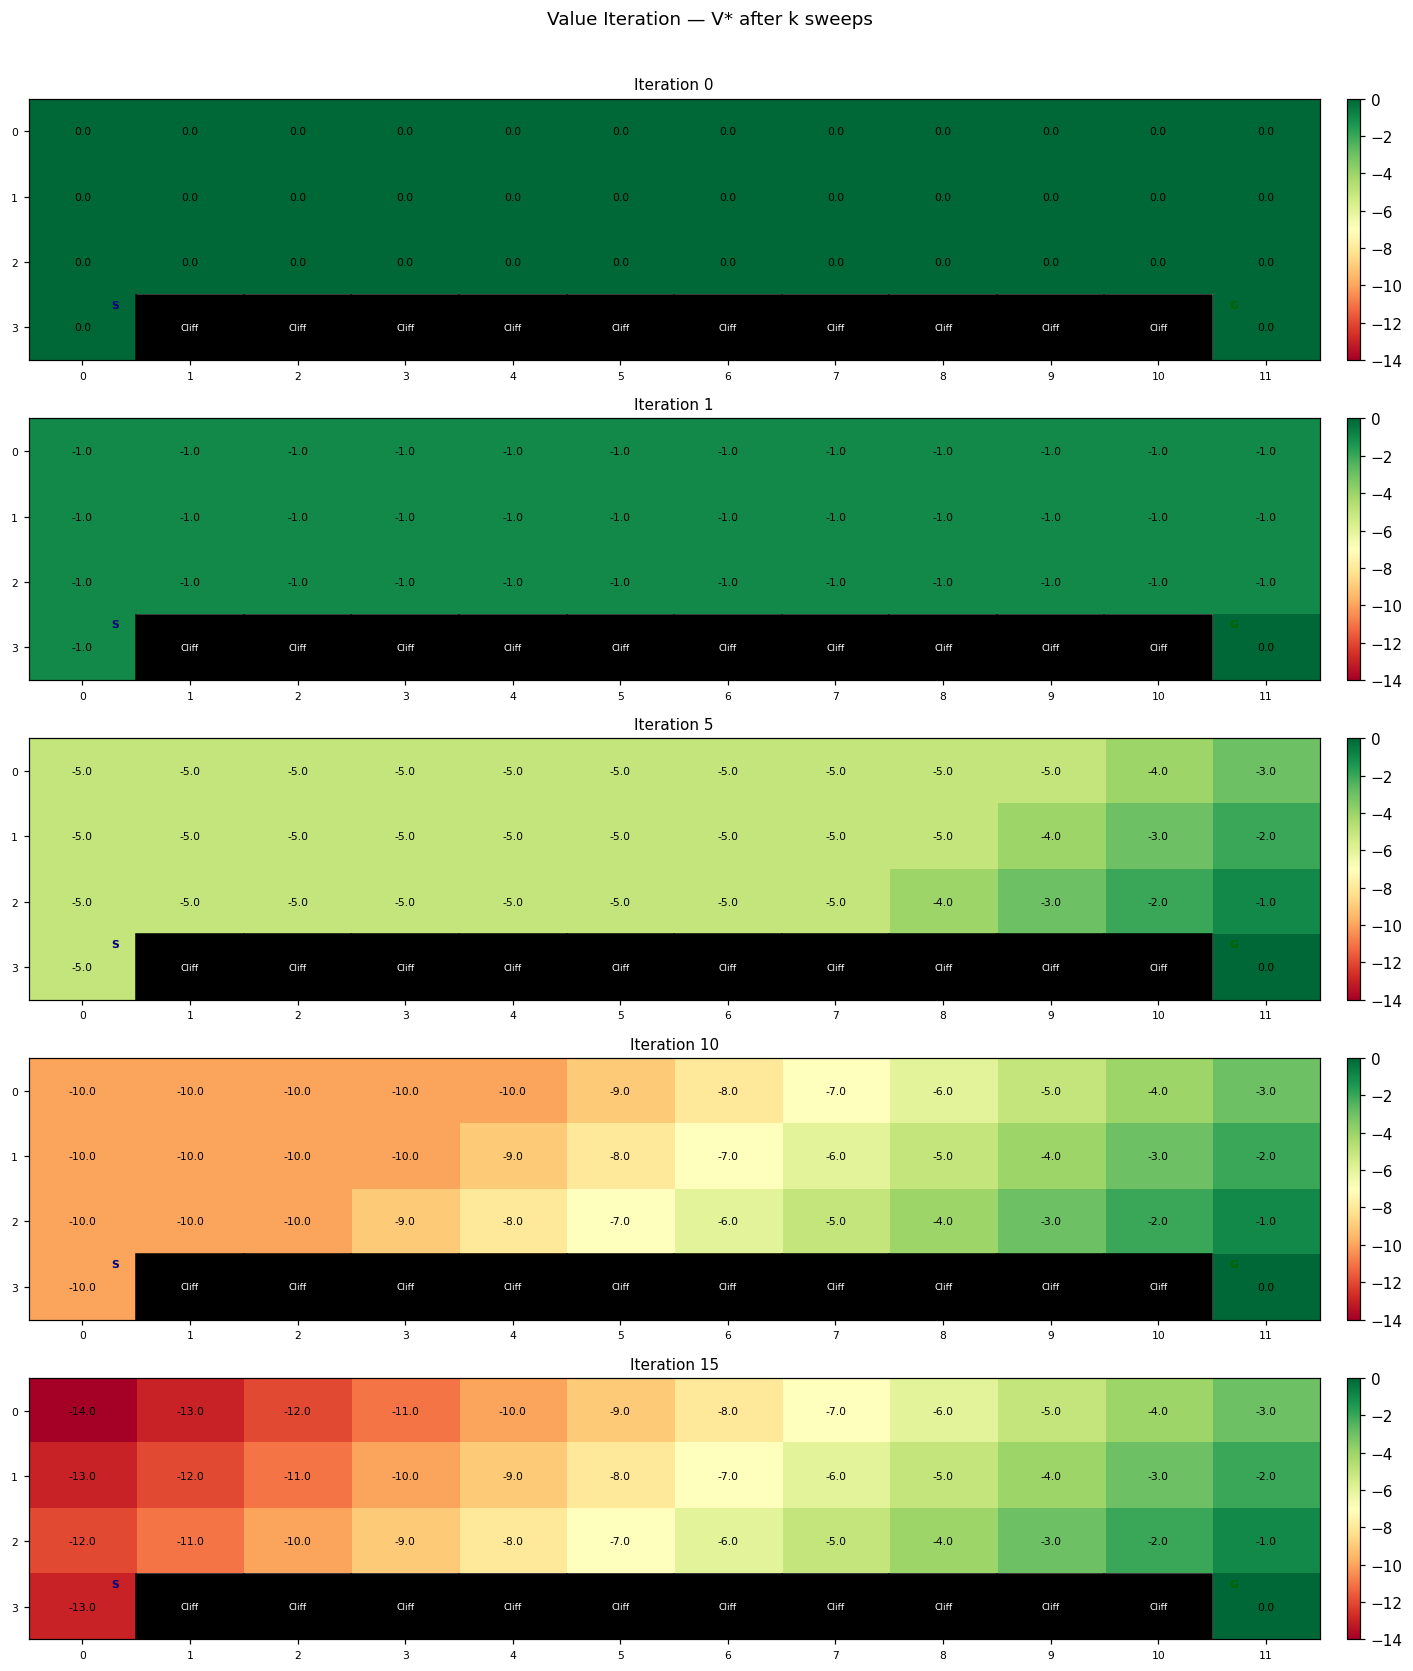

In [175]:
plot_convergence(history_vi, env,
                 iterations=(0, 1, 5, 10, 15),
                 title="Value Iteration — V* after k sweeps")
plt.show()

### Convergence diagnostics

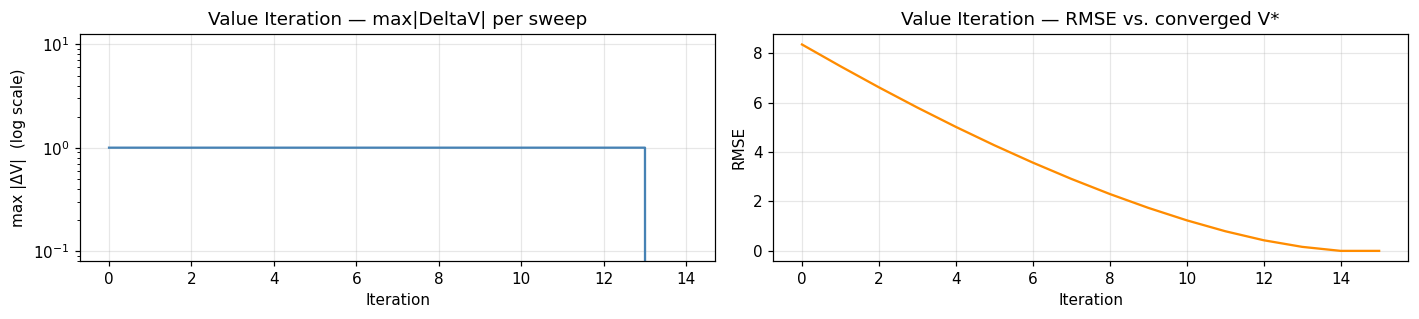

In [176]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 3))
plot_delta_curve(history_vi, ax=ax_l, title="Value Iteration — max|DeltaV| per sweep")
plot_rmse_curve(history_vi, V_ref=history_vi[-1], env=env, ax=ax_r,
                title="Value Iteration — RMSE vs. converged V*")
plt.tight_layout()
plt.show()

### Optimal policy

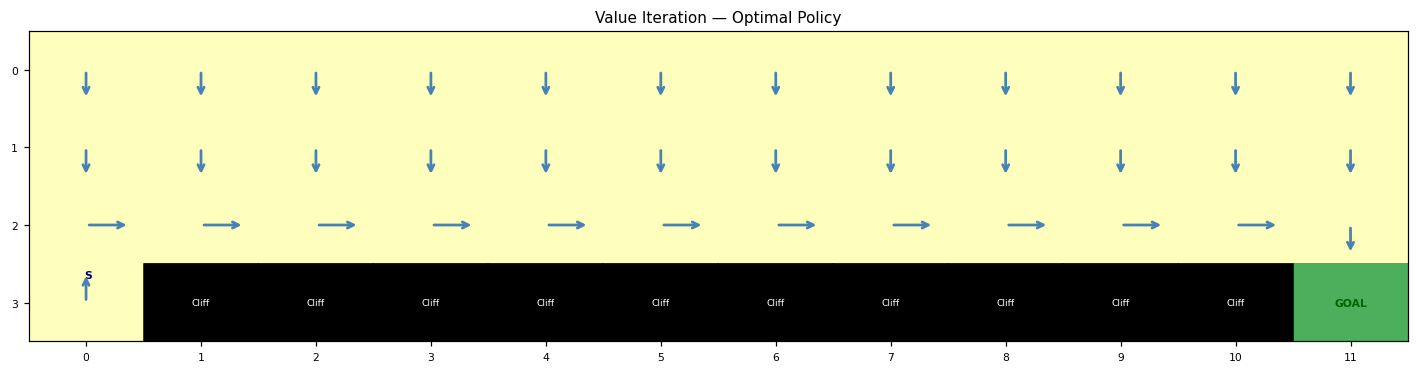

In [177]:
plot_policy(policy_vi, env, title="Value Iteration — Optimal Policy")
plt.show()

### Sanity check: PI and VI should yield the same $V^*$

In [178]:
print(f'Max |V_VI - V_PI| = {np.max(np.abs(V_vi - V_opt)):.2e}   (should be ~0)')

Max |V_VI - V_PI| = 0.00e+00   (should be ~0)


---
## 5 — Temporal Difference: TD(0) Policy Evaluation

### Background

**TD(0)** learns $V^\pi$ from experience without a model:

$$V(S_t) \leftarrow V(S_t) + \alpha \bigl[R_{t+1} + \gamma V(S_{t+1}) - V(S_t)\bigr]$$

The bracketed quantity $\delta_t$ is the **TD error**. Under standard step-size conditions, TD(0) converges to $V^\pi$ w.p. 1.

We evaluate the optimal policy $\pi^*$ from Policy Iteration and track convergence.

In [179]:
V_td, V_true, pi_dp = demo_td_evaluation(env, gamma=1.0, alpha=0.1, n_episodes=500)

TD(0) RMSE vs. true V after 500 episodes: 7.029


### Learned V vs. ground truth (after 500 episodes)

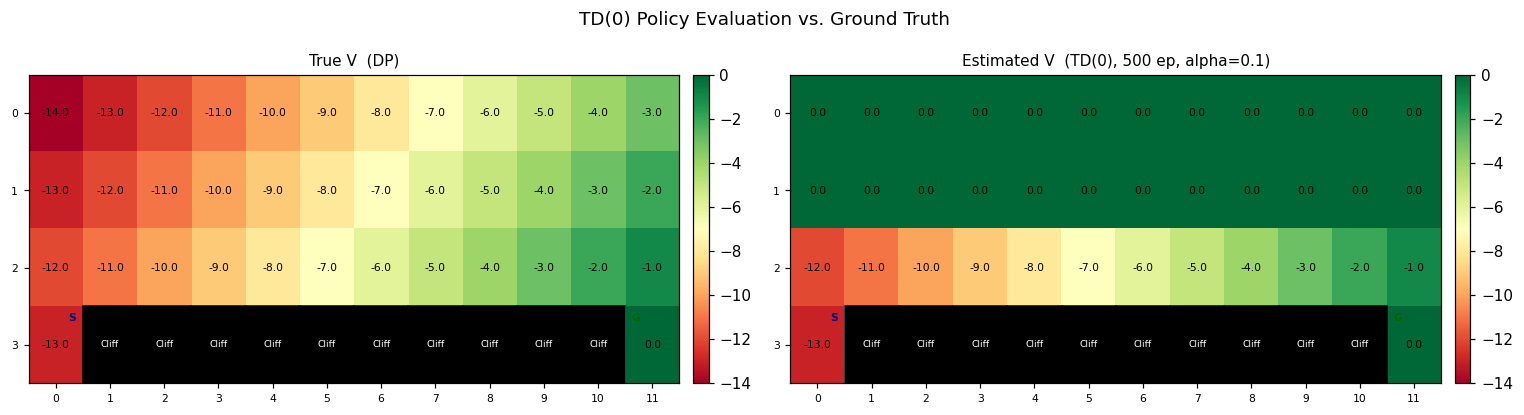

In [180]:
vmin = V_true.min()
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
plot_value_function(V_true, env, title="True V  (DP)",
                    ax=axes[0], vmin=vmin)
plot_value_function(V_td,   env, title="Estimated V  (TD(0), 500 ep, alpha=0.1)",
                    ax=axes[1], vmin=vmin)
fig.suptitle("TD(0) Policy Evaluation vs. Ground Truth", fontsize=12)
plt.tight_layout()
plt.show()

### How the estimate evolves — V snapshots at intermediate episodes

The value function starts at zero everywhere. As the agent samples more episodes it
gradually fills in the correct values, propagating backwards from the goal.

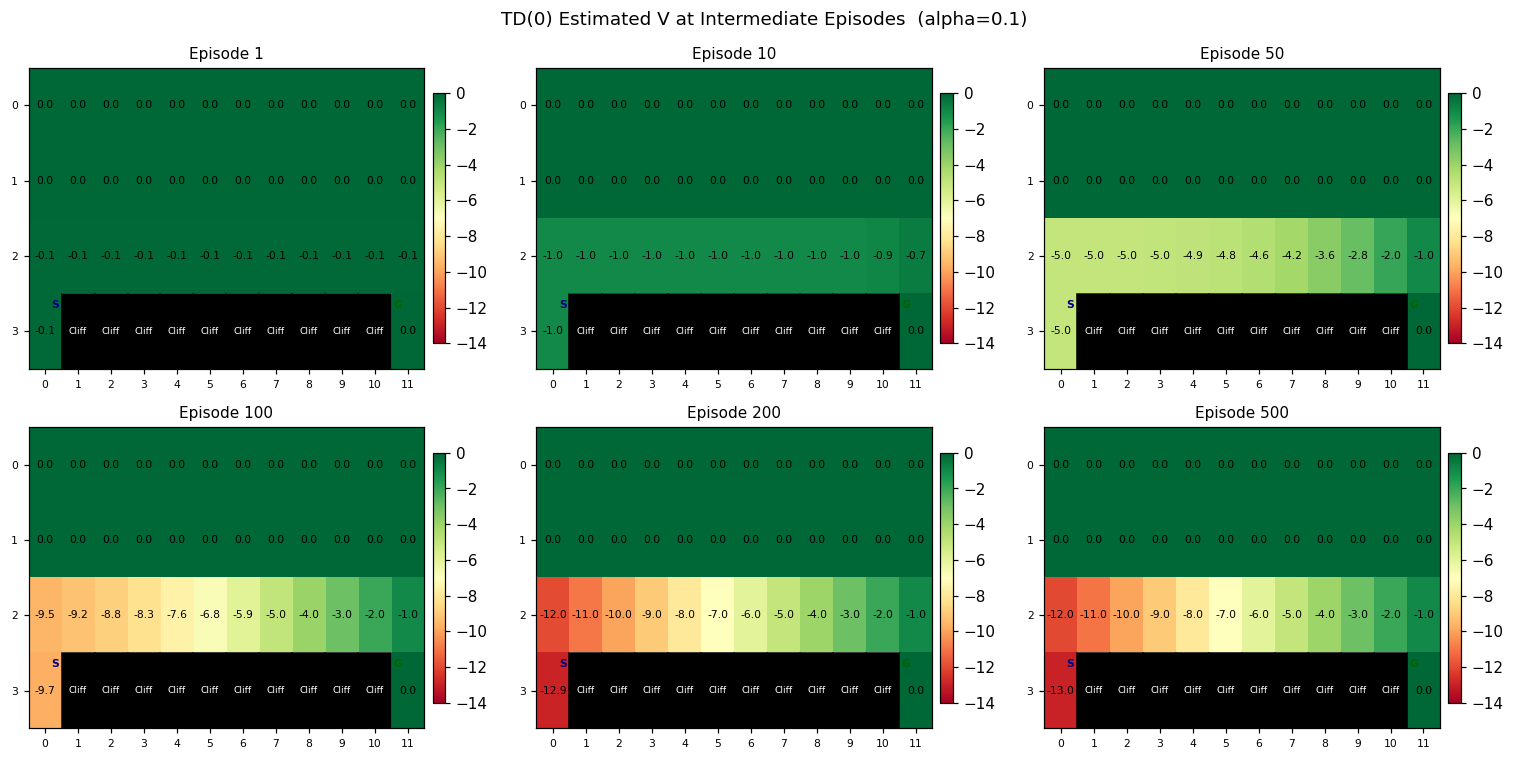

In [181]:
snap_eps = [1, 10, 50, 100, 200, 500]
_, _, td_snaps = td_evaluation(pi_dp, env, gamma=1.0, alpha=0.1,
                                n_episodes=500, snapshot_eps=snap_eps, seed=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, ep in zip(axes.flat, snap_eps):
    plot_value_function(td_snaps[ep], env,
                        title=f"Episode {ep}", ax=ax, vmin=vmin)
fig.suptitle("TD(0) Estimated V at Intermediate Episodes  (alpha=0.1)", fontsize=12)
plt.tight_layout()
plt.show()

### Effect of step-size: small alpha converges, large alpha oscillates

With a constant step-size $\alpha$, TD(0) does **not** converge to zero RMSE — it fluctuates
around the true value. Smaller $\alpha$ gives a tighter asymptotic bound at the cost of slower
initial learning. Very large $\alpha$ (e.g. $\alpha = 1$) causes persistent oscillation.

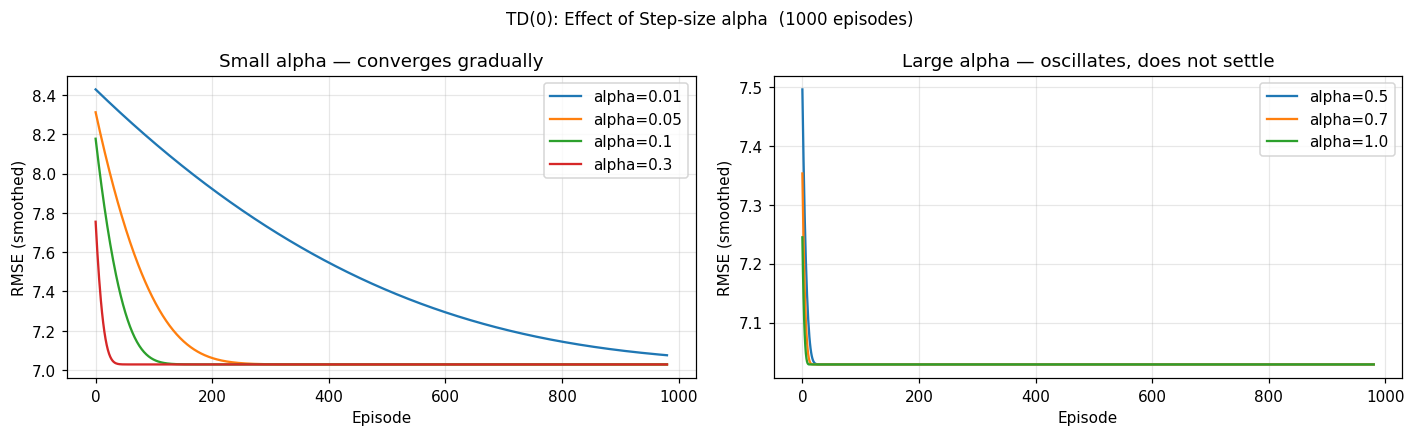

In [182]:
valid_idx = [env.state_index(s) for s in env.all_states()
             if s not in env.CLIFF and not env.is_terminal(s)]
n_ep = 1000

def _td_rmse_curve(policy, env, alpha, n_ep, V_ref, valid_idx):
    """Run TD(0) for n_ep episodes, return per-episode RMSE curve."""
    V, curve = np.zeros(env.n_states), []
    for _ in range(n_ep):
        state = env.START
        while not env.is_terminal(state):
            s  = env.state_index(state)
            ns_state, r, _ = env.step(state, policy[s])
            ns = env.state_index(ns_state)
            V[s] += alpha * (r + V[ns] - V[s])
            state = ns_state
        curve.append(np.sqrt(np.mean((V[valid_idx] - V_ref[valid_idx])**2)))
    return np.array(curve)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for alpha in [0.01, 0.05, 0.1, 0.3]:
    ax1.plot(smooth(_td_rmse_curve(pi_dp, env, alpha, n_ep, V_true, valid_idx), 20),
             label=f'alpha={alpha}')
ax1.set_xlabel('Episode'); ax1.set_ylabel('RMSE (smoothed)')
ax1.set_title('Small alpha — converges gradually')
ax1.legend(); ax1.grid(True, alpha=0.3)

for alpha in [0.5, 0.7, 1.0]:
    ax2.plot(smooth(_td_rmse_curve(pi_dp, env, alpha, n_ep, V_true, valid_idx), 20),
             label=f'alpha={alpha}')
ax2.set_xlabel('Episode'); ax2.set_ylabel('RMSE (smoothed)')
ax2.set_title('Large alpha — oscillates, does not settle')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('TD(0): Effect of Step-size alpha  (1000 episodes)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 6 — Temporal Difference: SARSA vs Q-learning

### Background

#### SARSA — On-policy TD Control
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\bigl[R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)\bigr]$$
$A_{t+1}$ drawn from the **same** epsilon-greedy policy — *on-policy*.

#### Q-learning — Off-policy TD Control
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\bigl[R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a') - Q(S_t, A_t)\bigr]$$
Uses the **greedy** next action regardless of behaviour — *off-policy*.

### The Cliff Gridworld Contrast
* **Q-learning** learns the *optimal* path along row 3 (next to the cliff). The epsilon-greedy
  behaviour occasionally falls off, hurting online performance.
* **SARSA** learns the *safer* path along row 2 — accounting for the epsilon-greedy noise — and
  achieves higher online reward during training.

In [183]:
# Multi-seed averages for learning curves
N_SEEDS   = 30
N_EP      = 500
ALPHA     = 0.5
EPSILON   = 0.1

results = demo_sarsa_qlearning(
    env, gamma=1.0, alpha=ALPHA, epsilon=EPSILON,
    n_episodes=N_EP, n_seeds=N_SEEDS
)

# Single-seed runs with Q / trajectory snapshots for policy-evolution and trajectory plots
SNAP_EPS = [1, 50, 100, 250, 500]
print('Running SARSA snapshots …')
_, _, sarsa_pi_snap, sarsa_traj_snap = sarsa_snapshots(
    env, gamma=1.0, alpha=ALPHA, epsilon=EPSILON,
    n_episodes=N_EP, snapshot_eps=SNAP_EPS, seed=0
)
print('Running Q-learning snapshots …')
_, _, ql_pi_snap, ql_traj_snap = q_learning_snapshots(
    env, gamma=1.0, alpha=ALPHA, epsilon=EPSILON,
    n_episodes=N_EP, snapshot_eps=SNAP_EPS, seed=0
)

Running SARSA × 30 seeds …
Running Q-learning × 30 seeds …
Running SARSA snapshots …
Running Q-learning snapshots …


### Learning curves (standard error over 30 seeds)

Shaded bands show $\pm 1$ **standard error** (SE = std / sqrt(n_seeds)), not std.
SE measures uncertainty in the *mean*, giving narrower, more interpretable bands.

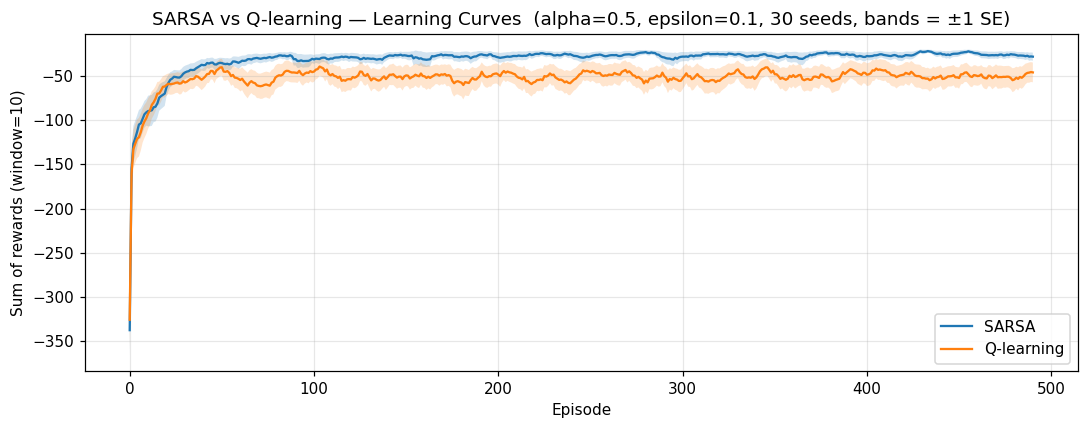

In [184]:
sarsa_se = results['sarsa_std'] / np.sqrt(N_SEEDS)
ql_se    = results['ql_std']    / np.sqrt(N_SEEDS)

fig, ax = plt.subplots(figsize=(10, 4))
plot_learning_curves(
    {"SARSA":      (results['sarsa_mean'], sarsa_se),
     "Q-learning": (results['ql_mean'],   ql_se)},
    window=10,
    title=f"SARSA vs Q-learning — Learning Curves  "
          f"(alpha={ALPHA}, epsilon={EPSILON}, {N_SEEDS} seeds, bands = ±1 SE)",
    ax=ax,
)
plt.tight_layout()
plt.show()

### Greedy trajectory evolution during training

After each checkpoint episode we freeze training and run one **greedy** (epsilon=0) episode
to see what path the current policy takes.  Red arrows show the route; cell brightness shows
visit count (darker = visited more often, relevant when the agent loops).

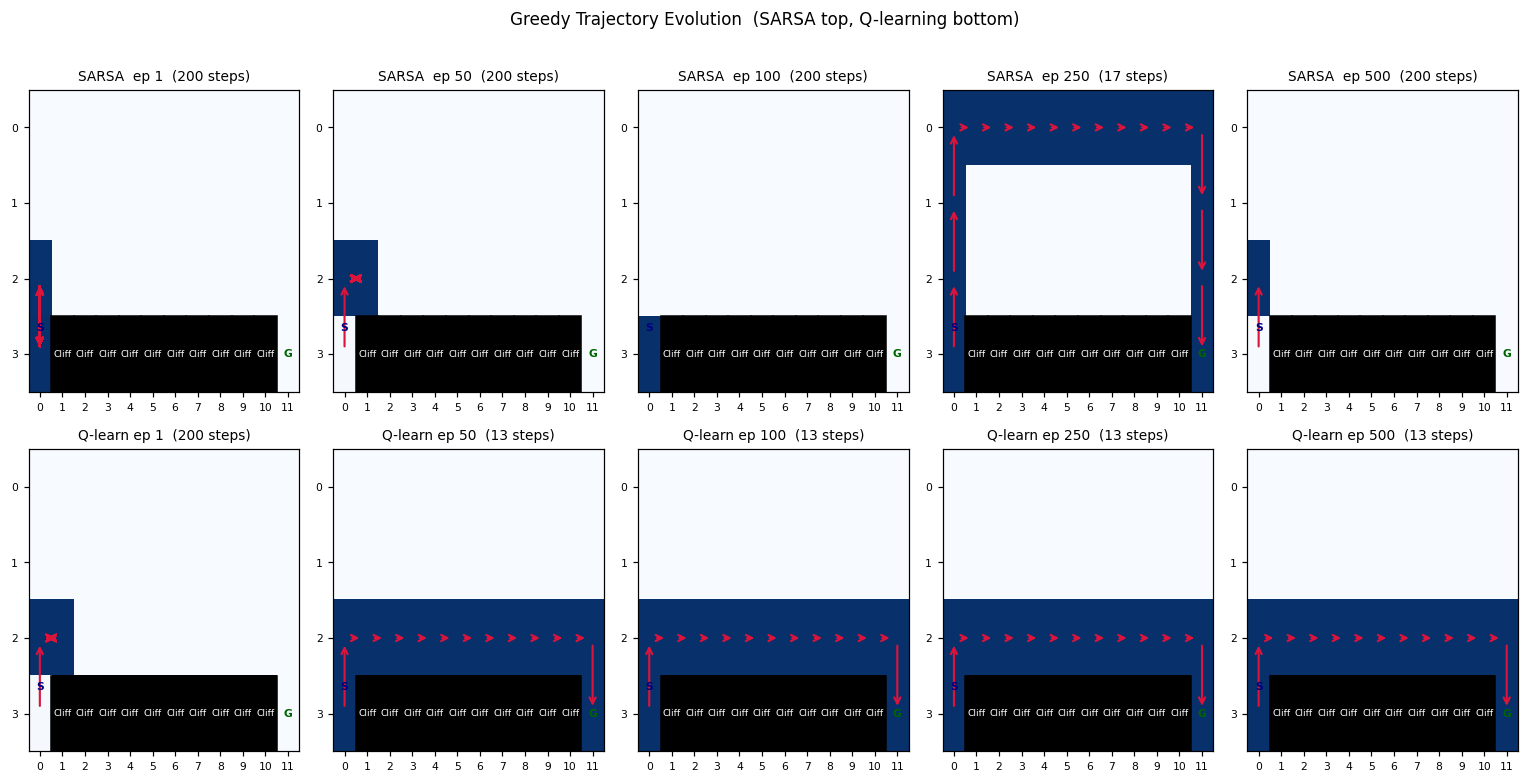

In [185]:
fig, axes = plt.subplots(2, len(SNAP_EPS), figsize=(14, 7))
for i, ep in enumerate(SNAP_EPS):
    plot_trajectory(sarsa_traj_snap[ep], env,
                    title=f"SARSA  ep {ep}", ax=axes[0, i])
    plot_trajectory(ql_traj_snap[ep],    env,
                    title=f"Q-learn ep {ep}", ax=axes[1, i])
fig.suptitle("Greedy Trajectory Evolution  (SARSA top, Q-learning bottom)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Greedy policy evolution during training

Each panel shows the **greedy policy** (argmax Q) at a training checkpoint.
SARSA's policy gradually avoids the cliff row; Q-learning's policy converges to the
row-3 optimal path.

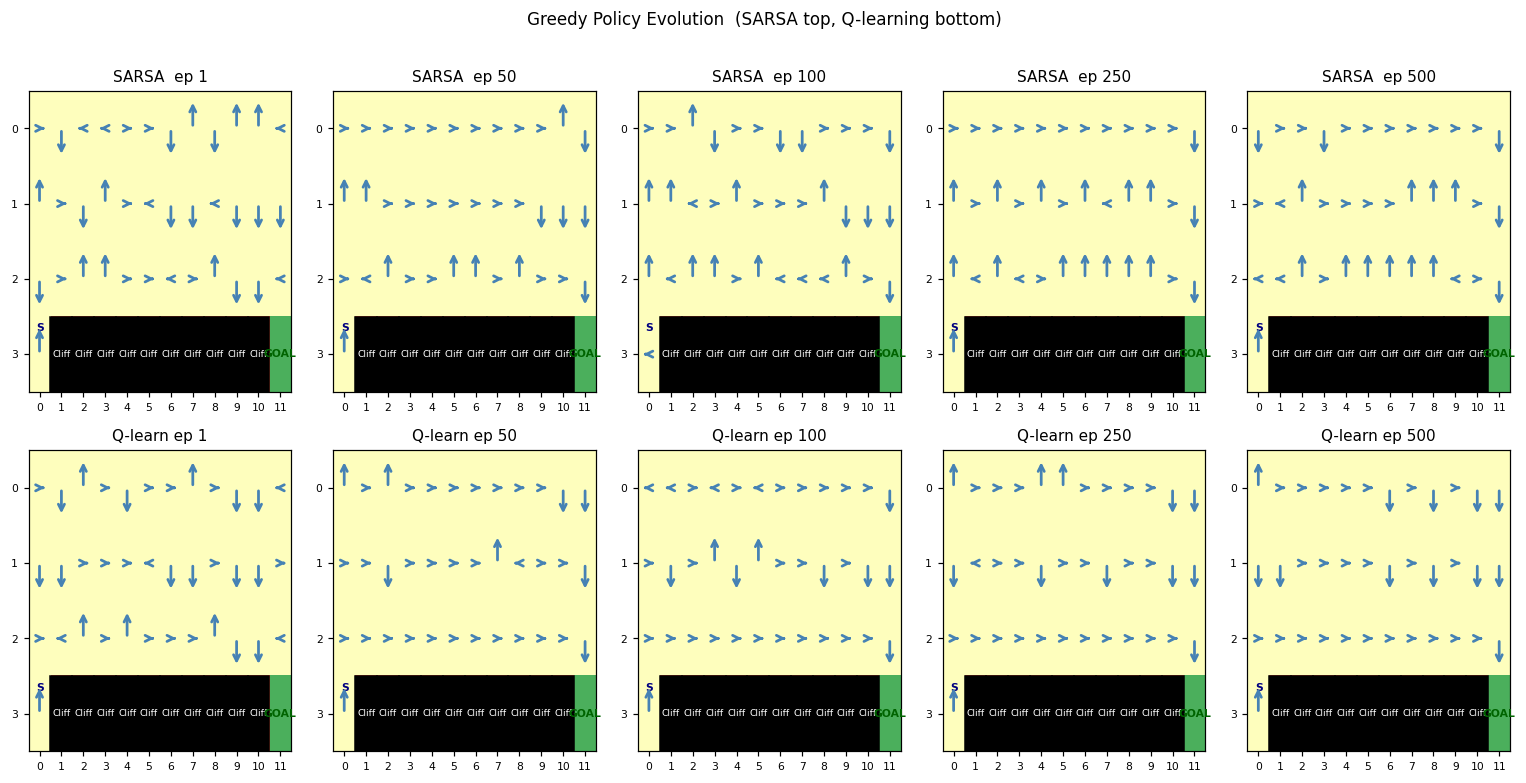

In [186]:
fig, axes = plt.subplots(2, len(SNAP_EPS), figsize=(14, 7))
for i, ep in enumerate(SNAP_EPS):
    plot_policy(sarsa_pi_snap[ep], env,
                title=f"SARSA  ep {ep}",  ax=axes[0, i])
    plot_policy(ql_pi_snap[ep],    env,
                title=f"Q-learn ep {ep}", ax=axes[1, i])
fig.suptitle("Greedy Policy Evolution  (SARSA top, Q-learning bottom)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Final greedy policies and value functions

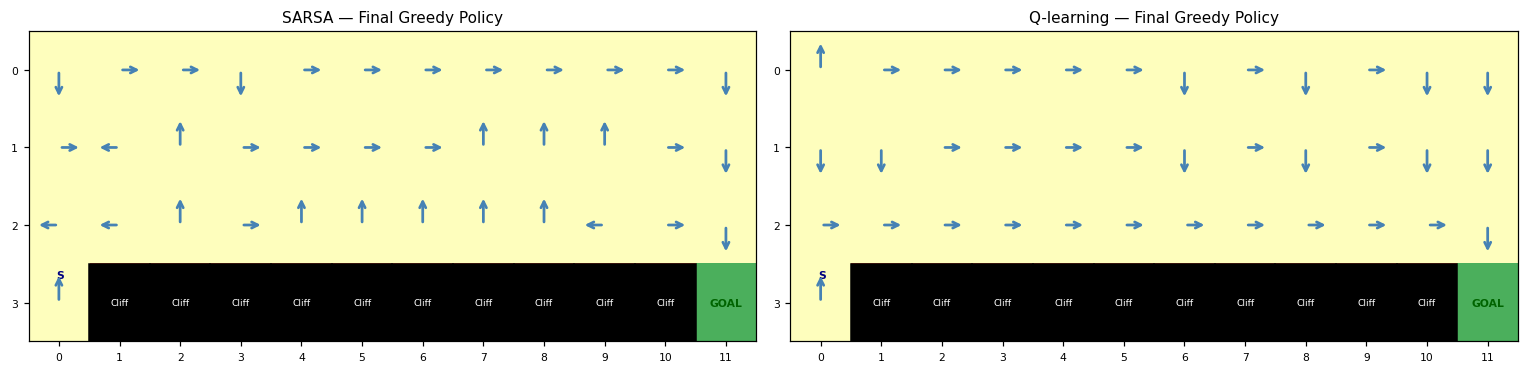

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_policy(results['pi_sarsa'], env, title="SARSA — Final Greedy Policy",     ax=axes[0])
plot_policy(results['pi_ql'],    env, title="Q-learning — Final Greedy Policy", ax=axes[1])
plt.tight_layout()
plt.show()

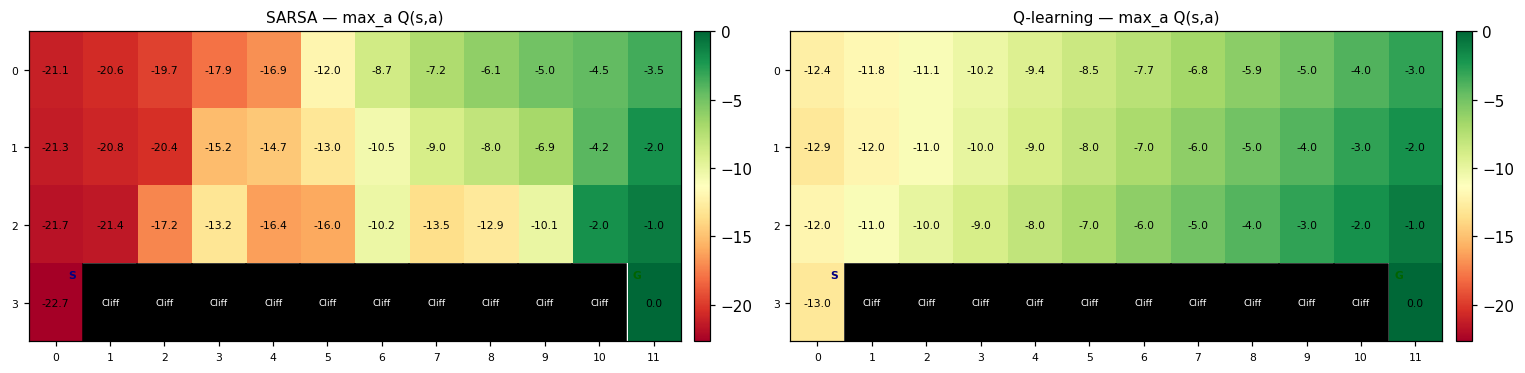

In [188]:
V_sarsa = results['Q_sarsa'].max(axis=1)
V_ql    = results['Q_ql'].max(axis=1)
vmin_q  = min(V_sarsa.min(), V_ql.min())

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 3.5))
plot_value_function(V_sarsa, env, title="SARSA — max_a Q(s,a)",     ax=ax3, vmin=vmin_q)
plot_value_function(V_ql,    env, title="Q-learning — max_a Q(s,a)", ax=ax4, vmin=vmin_q)
plt.tight_layout()
plt.show()

### Effect of epsilon on the SARSA / Q-learning gap

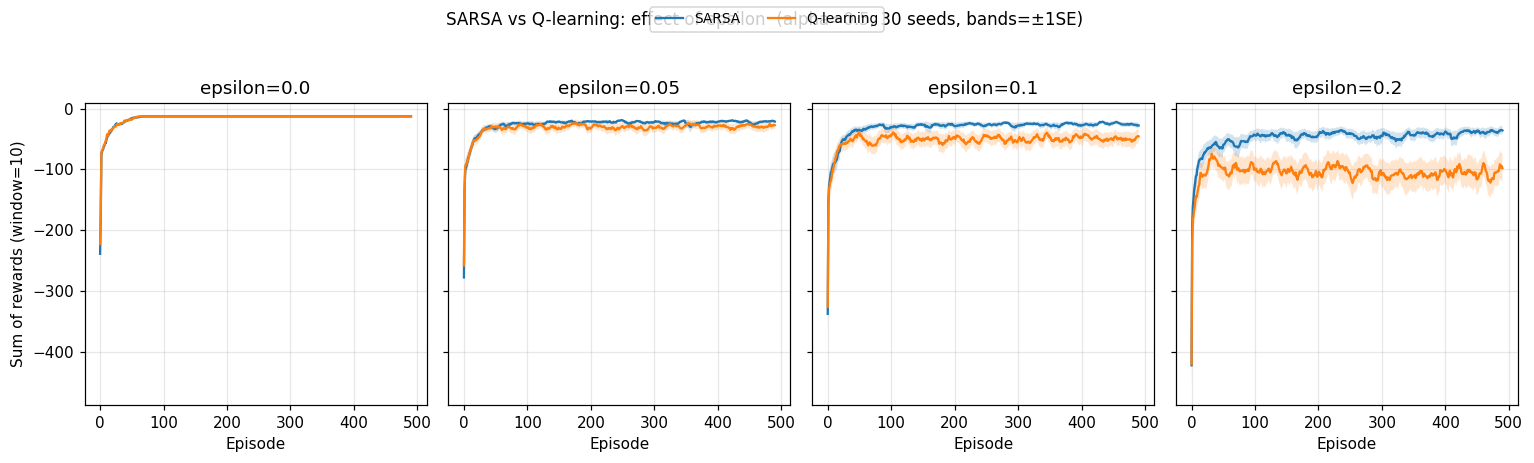

In [189]:
epsilons = [0.0, 0.05, 0.1, 0.2]
fig, axes = plt.subplots(1, len(epsilons), figsize=(14, 4), sharey=True)

for ax, eps in zip(axes, epsilons):
    sm, ss = run_multiple_seeds(sarsa,      env, n_seeds=N_SEEDS,
                                 gamma=1.0, alpha=ALPHA, epsilon=eps, n_episodes=N_EP)
    qm, qs = run_multiple_seeds(q_learning, env, n_seeds=N_SEEDS,
                                 gamma=1.0, alpha=ALPHA, epsilon=eps, n_episodes=N_EP)
    plot_learning_curves(
        {'SARSA': (sm, ss / np.sqrt(N_SEEDS)),
         'Q-learning': (qm, qs / np.sqrt(N_SEEDS))},
        window=10, title=f'epsilon={eps}', ax=ax,
    )
    if ax is not axes[0]:
        ax.set_ylabel('')
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9)
fig.suptitle(f'SARSA vs Q-learning: effect of epsilon  (alpha={ALPHA}, {N_SEEDS} seeds, bands=±1SE)',
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()

---
## 7 — Policy Gradient: REINFORCE and Actor-Critic

### Background

Policy gradient methods parameterise the policy directly as a tabular softmax:
$$\pi(a \mid s;\,\theta) = \frac{\exp(\theta[s,a])}{\sum_{a'}\exp(\theta[s,a'])}$$
and optimise $J(\theta) = \mathbb{E}_\pi[G_0]$ by gradient ascent.
The **Policy Gradient Theorem** gives $\nabla J(\theta) \propto \mathbb{E}_\pi[G_t \nabla\log\pi(A_t|S_t;\theta)]$.
Score function: $\nabla\log\pi(a_t|s_t;\theta) = \mathbf{e}_{a_t} - \pi(\cdot|s_t;\theta)$.

---

#### REINFORCE
$$\theta \leftarrow \theta + \alpha\,\gamma^t\,G_t\,\nabla\log\pi(A_t|S_t;\theta)$$
High variance: $G_t$ accumulates many random rewards.

#### REINFORCE with Baseline
$$\delta = G_t - V(S_t;w), \quad w[S_t] \leftarrow w[S_t] + \alpha_w\delta$$
$$\theta \leftarrow \theta + \alpha_\theta\,\gamma^t\,\delta\,\nabla\log\pi(A_t|S_t;\theta)$$
Baseline does **not** bias the gradient ($\mathbb{E}[\nabla\log\pi \cdot b(s)]=0$) but reduces variance.

#### One-step Actor-Critic
$$\delta_t = R_{t+1} + \gamma V(S_{t+1};w) - V(S_t;w), \quad w[S_t] \leftarrow w[S_t]+\alpha_w\delta_t$$
$$\theta \leftarrow \theta + \alpha_\theta\,\gamma^t\,\delta_t\,\nabla\log\pi(A_t|S_t;\theta)$$
Online updates (per step, not per episode) — lower variance, some bias from bootstrapping.

| Algorithm | Return estimate | Update freq | Variance | Bias |
|---|---|:---:|:---:|:---:|
| REINFORCE | $G_t$ (MC) | per episode | High | None |
| REINFORCE+baseline | $G_t-V(s)$ (MC) | per episode | Lower | None |
| Actor-Critic | $\delta_t$ (TD) | per step | Low | Some |

In [199]:
PG_SEEDS    = 5
PG_EPISODES = 100

pg = demo_policy_gradient(
    env,
    gamma=1.0,
    alpha_reinforce=0.005,   # REINFORCE actor step-size
    alpha_theta=0.005,        # actor step-size (baseline / AC)
    alpha_w=0.1,              # critic/baseline step-size — must learn fast to reduce variance
    n_episodes=PG_EPISODES,
    n_seeds=PG_SEEDS,
)

Running REINFORCE × 5 seeds …
Running REINFORCE + baseline × 5 seeds …
Running Actor-Critic × 5 seeds …


### Learning curves

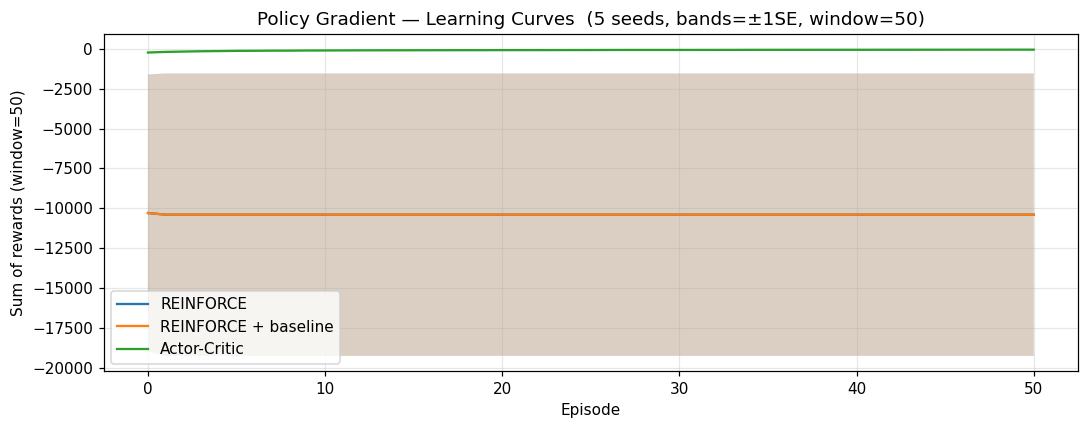

In [200]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_learning_curves(
    {"REINFORCE":            (pg['rf_mean'],  pg['rf_std']  / np.sqrt(PG_SEEDS)),
     "REINFORCE + baseline": (pg['rfb_mean'], pg['rfb_std'] / np.sqrt(PG_SEEDS)),
     "Actor-Critic":         (pg['ac_mean'],  pg['ac_std']  / np.sqrt(PG_SEEDS))},
    window=50,
    title=f"Policy Gradient — Learning Curves  ({PG_SEEDS} seeds, bands=±1SE, window=50)",
    ax=ax,
)
plt.tight_layout()
plt.show()

### Greedy policies

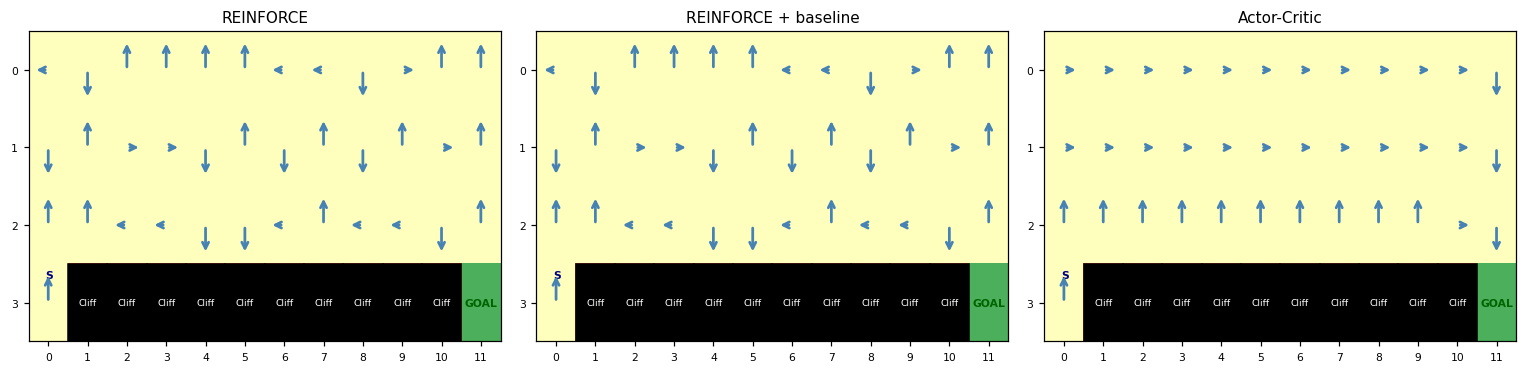

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
plot_policy(pg['pi_rf'],  env, title="REINFORCE",             ax=axes[0])
plot_policy(pg['pi_rfb'], env, title="REINFORCE + baseline",  ax=axes[1])
plot_policy(pg['pi_ac'],  env, title="Actor-Critic",          ax=axes[2])
plt.tight_layout()
plt.show()

### Learned value functions (critic weights $w$)

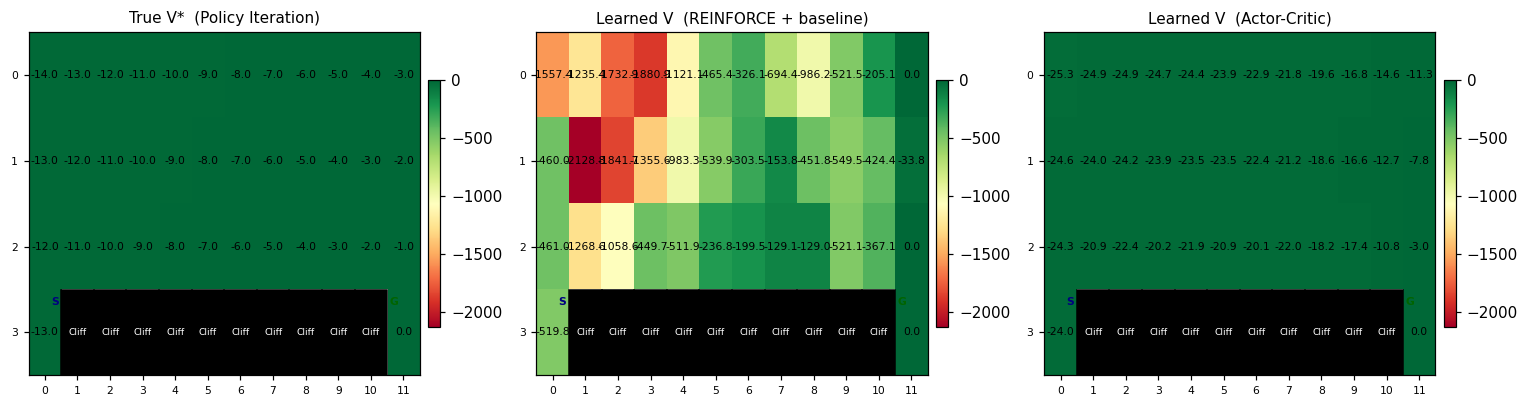

In [ ]:
vmin = min(V_opt.min(), pg['w_rfb'].min(), pg['w_ac'].min())
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_value_function(V_opt,       env, title="True V*  (Policy Iteration)",       ax=axes[0], vmin=vmin)
plot_value_function(pg['w_rfb'], env, title="Learned V  (REINFORCE + baseline)", ax=axes[1], vmin=vmin)
plot_value_function(pg['w_ac'],  env, title="Learned V  (Actor-Critic)",          ax=axes[2], vmin=vmin)
plt.tight_layout()
plt.show()

### Softmax action probabilities at the start state

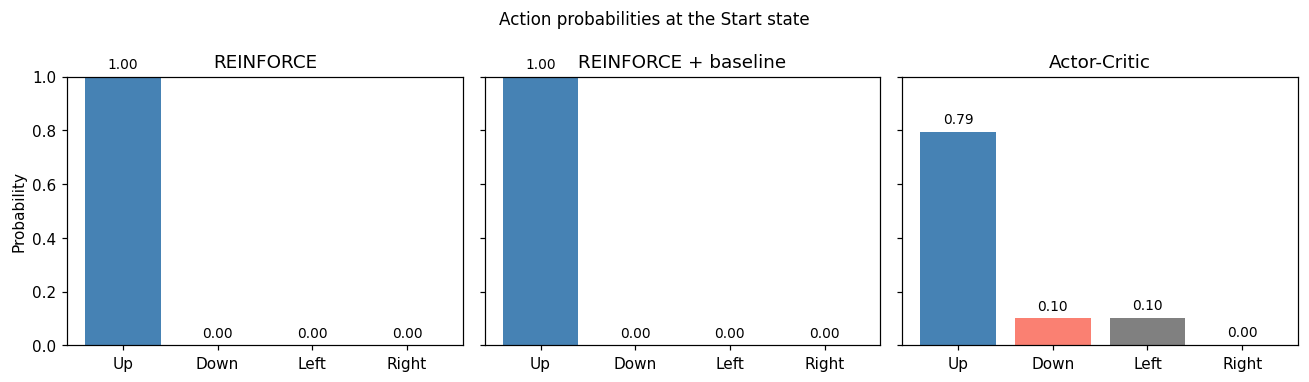

In [ ]:
from cliff import _softmax

s_idx = env.state_index(env.START)
algos = [("REINFORCE", pg['theta_rf']),
         ("REINFORCE + baseline", pg['theta_rfb']),
         ("Actor-Critic", pg['theta_ac'])]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (label, theta) in zip(axes, algos):
    probs = _softmax(theta[s_idx])
    bars  = ax.bar(env.ACTION_NAMES, probs,
                   color=['steelblue', 'salmon', 'gray', 'green'])
    ax.set_ylim(0, 1)
    ax.set_title(label)
    ax.set_ylabel('Probability' if ax is axes[0] else '')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, p + 0.02,
                f'{p:.2f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Action probabilities at the Start state', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

| Algorithm | Model needed | Policy type | Update target | Convergence to |
|---|:---:|---|---|---|
| Bellman Operator (PE) | Yes | Deterministic | $V^\pi$ (expectation) | $V^\pi$ |
| Policy Iteration | Yes | Deterministic | $V^{\pi_k}$ then improve | $V^*$, $\pi^*$ |
| Value Iteration | Yes | Deterministic | $V^*$ (optimality) | $V^*$, $\pi^*$ |
| TD(0) | No | Deterministic | $R + \gamma V(S')$ | $V^\pi$ |
| SARSA | No | Epsilon-greedy | $R + \gamma Q(S', A')$ on-policy | $Q^{\pi_\varepsilon}$ |
| Q-learning | No | Epsilon-greedy | $R + \gamma \max_{a'} Q(S', a')$ off-policy | $Q^*$ |
| REINFORCE | No | Stochastic (softmax) | $G_t$ (MC) | local opt. of $J(\theta)$ |
| REINFORCE + baseline | No | Stochastic (softmax) | $G_t - V(s)$ (MC) | local opt. of $J(\theta)$ |
| Actor-Critic | No | Stochastic (softmax) | $\delta_t$ (TD) | local opt. of $J(\theta)$ |

PE = Policy Evaluation.